Checkpoint: /home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32/version_1/checkpoints/epoch=44-step=21105.ckpt
Prediction file: /home/apaudel/NuGraph/scripts/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1_test_predictions.h5
Output directory: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1

Important checkpoint hyperparameters:
in_features: 8
hit_features: 128
nexus_features: 32
interaction_features: 32
instance_features: 8
event_classes: ['cc_nue', 'es_nue']
event_head: True
semantic_head: False
filter_head: False
use_optical: False
lr: 0.001

Class ordering from checkpoint:
  0: cc_nue
  1: es_nue

Resolved class indices:
  CC index: 0
  ES index: 1

Run directory: /home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32/version_1

TensorBoard event files:
  /home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32/version_1/events.out.tfevents.1784749701.jupyter-apaudel.6

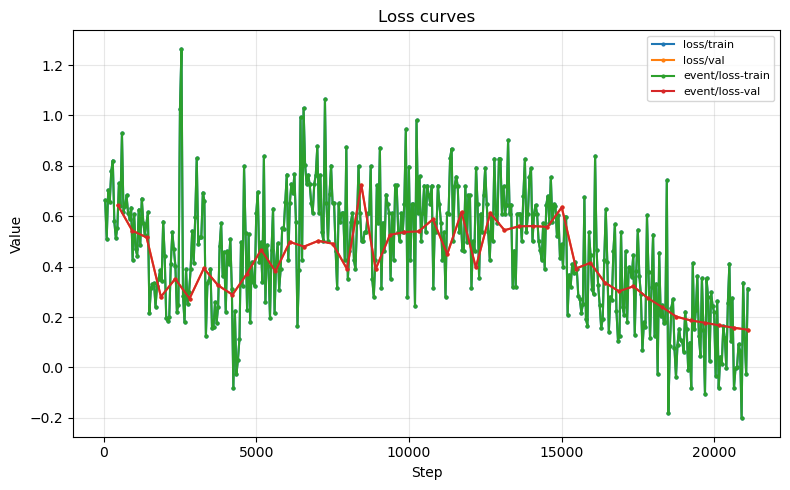

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/loss_curves.png


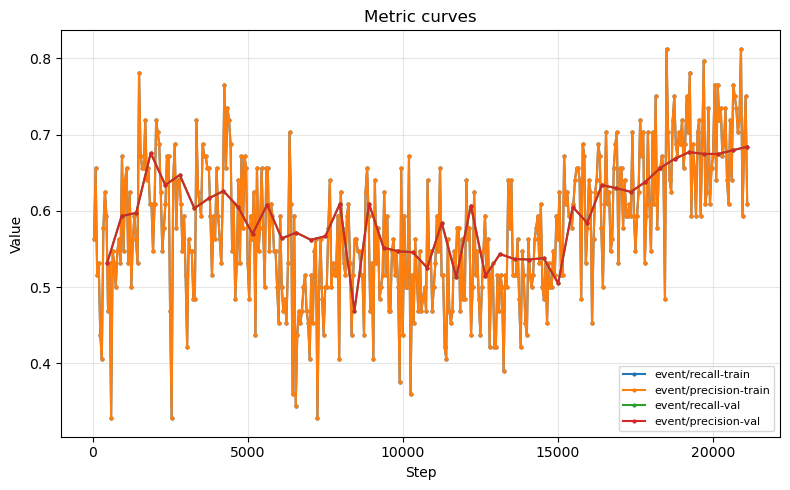

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/metric_curves.png


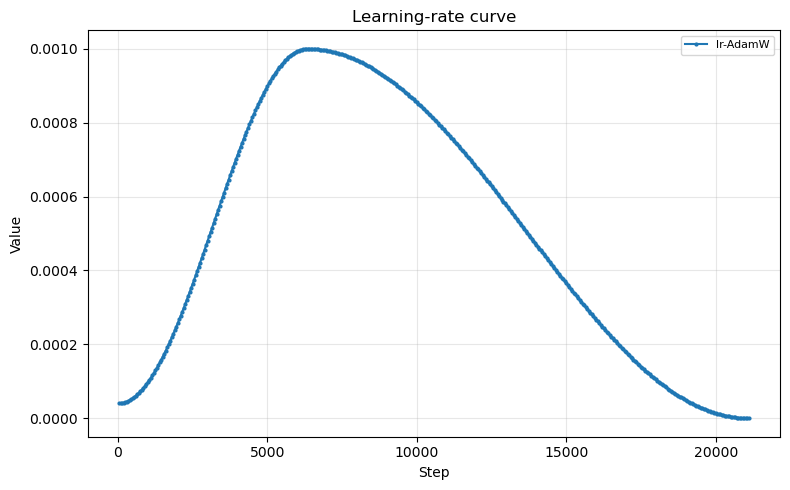

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/learning_rate_curve.png

TensorBoard image tags found:
  event/recall-matrix-val
  event/precision-matrix-val

Displaying latest image for each TensorBoard image tag:

Tag: event/recall-matrix-val
Step: 45
Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/event_recall-matrix-val_latest_step45.png


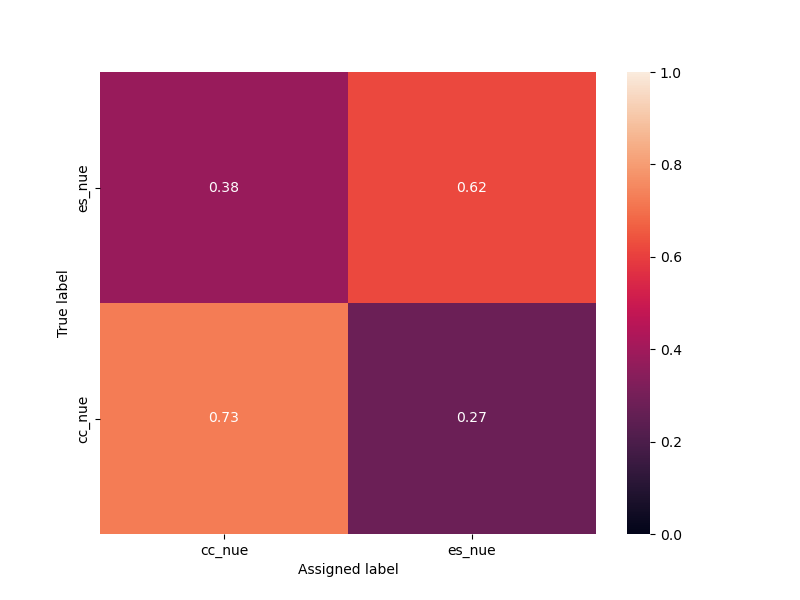


Tag: event/precision-matrix-val
Step: 45
Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/event_precision-matrix-val_latest_step45.png


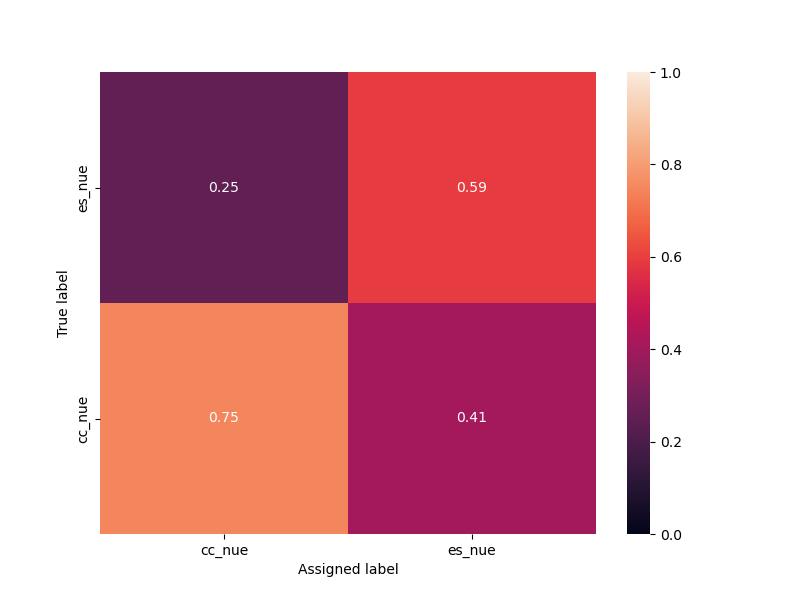


Available HDF keys: ['/events']

Prediction dataframe columns:
['run', 'subrun', 'event', 'y_true', 'y_pred', 'prob_cc_nue', 'prob_es_nue']

First five rows:


,run,subrun,event,y_true,y_pred,prob_cc_nue,prob_es_nue
0,20000216,216,10797,0,0,0.521358,0.478642
1,20000394,394,39686,1,0,0.593291,0.406709
2,20000340,340,36976,1,1,0.386703,0.613297
3,20000071,71,3508,0,1,0.386957,0.613043
4,20000238,238,11873,0,0,0.696278,0.303722



Unique y_true counts:
{np.int64(0): np.int64(980), np.int64(1): np.int64(689)}

Unique y_pred counts:
{np.int64(0): np.int64(981), np.int64(1): np.int64(688)}

Using probability columns:
  P(CC): prob_cc_nue
  P(ES): prob_es_nue

Probability sum check:
  min: 0.999999925494194
  max: 1.000000074505806
  mean: 1.000000000764477

Critical sanity check:
  argmax(probabilities) == y_pred fraction: 1.0000
OK: y_pred matches probability argmax.

Number of test events: 1669
Overall accuracy:       0.6771

Confusion matrix counts:


,Predicted ES,Predicted CC
True CC,269,711
True ES,419,270



Row-normalized confusion matrix:


,Predicted ES,Predicted CC
True CC,0.2745,0.7255
True ES,0.6081,0.3919


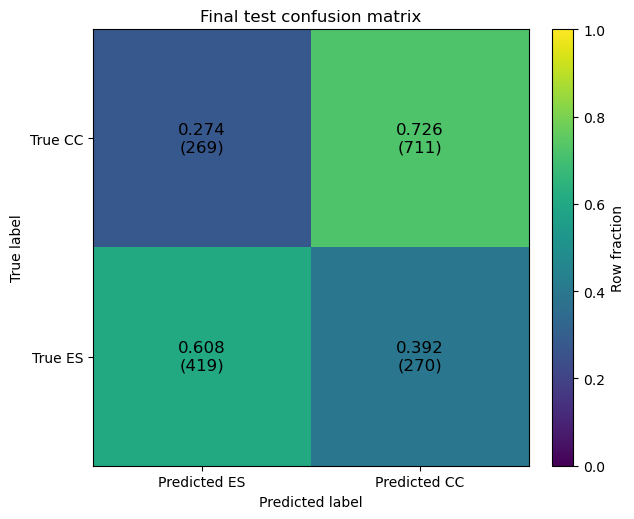

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/final_test_confusion_matrix.png

Average probabilities:
True CC: average P(CC) = 0.5879
True CC: average P(ES) = 0.4121
True ES: average P(ES) = 0.5300
True ES: average P(CC) = 0.4700


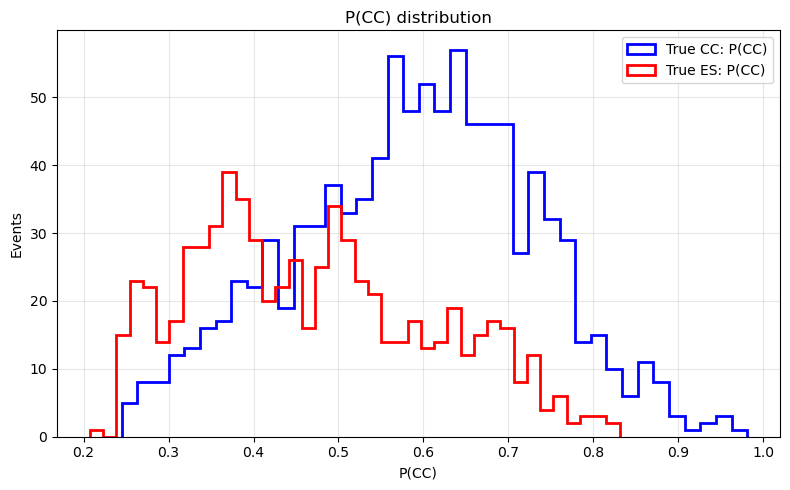

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/pcc_distribution.png


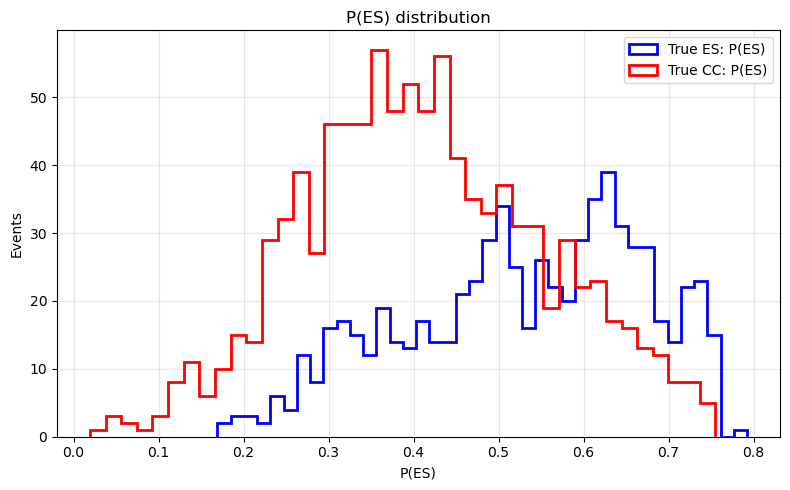

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1/pes_distribution.png

Done. Saved plots in:
/home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1


In [1]:
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


# =============================================================================
# Paths for this specific run
# =============================================================================

CKPT = "/home/apaudel/NuGraph/logs/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32/version_1/checkpoints/epoch=44-step=21105.ckpt"

PRED_H5 = "/home/apaudel/NuGraph/scripts/merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1_test_predictions.h5"

OUTDIR = "/home/apaudel/NuGraph/scripts/plots_merged1_July21_40k_tpc_only_ep45_bs64_in8_int32_version1"
os.makedirs(OUTDIR, exist_ok=True)


# =============================================================================
# Helper functions
# =============================================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def get_run_dir_from_ckpt(ckpt_path):
    # .../version_1/checkpoints/epoch=...ckpt -> .../version_1
    return os.path.dirname(os.path.dirname(ckpt_path))


def load_event_accumulator(run_dir):
    event_files = glob.glob(os.path.join(run_dir, "events.out.tfevents.*"))

    if not event_files:
        print("No TensorBoard event files found in:", run_dir)
        return None

    print("\nTensorBoard event files:")
    for f in event_files:
        print(" ", f)

    ea = EventAccumulator(run_dir, size_guidance={"scalars": 0, "images": 0})
    ea.Reload()
    return ea


def scalar_to_df(ea, tag):
    vals = ea.Scalars(tag)
    return pd.DataFrame({
        "step": [v.step for v in vals],
        "value": [v.value for v in vals],
        "wall_time": [v.wall_time for v in vals],
    })


def plot_scalar_group(ea, tags, title, outfile):
    if ea is None:
        return

    available = ea.Tags().get("scalars", [])
    tags = [tag for tag in tags if tag in available]

    if not tags:
        print(f"No scalar tags found for: {title}")
        return

    plt.figure(figsize=(8, 5))

    for tag in tags:
        df_tag = scalar_to_df(ea, tag)
        plt.plot(df_tag["step"], df_tag["value"], marker="o", markersize=2, linewidth=1.5, label=tag)

    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


def save_and_display_tensorboard_images(ea, outdir):
    if ea is None:
        return

    image_tags = ea.Tags().get("images", [])

    if not image_tags:
        print("\nNo TensorBoard image tags found.")
        return

    print("\nTensorBoard image tags found:")
    for tag in image_tags:
        print(" ", tag)

    print("\nDisplaying latest image for each TensorBoard image tag:")

    for tag in image_tags:
        imgs = ea.Images(tag)
        if not imgs:
            continue

        latest = imgs[-1]
        safe_name = tag.replace("/", "_").replace(" ", "_")
        outfile = os.path.join(outdir, f"{safe_name}_latest_step{latest.step}.png")

        with open(outfile, "wb") as f:
            f.write(latest.encoded_image_string)

        print(f"\nTag: {tag}")
        print(f"Step: {latest.step}")
        print("Saved:", outfile)
        display(Image(filename=outfile))


def plot_confusion_matrix(cm_counts, outfile):
    cm_fraction = cm_counts / cm_counts.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6.6, 5.3))
    im = ax.imshow(cm_fraction, vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted ES", "Predicted CC"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["True CC", "True ES"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Final test confusion matrix")

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm_fraction[i, j]:.3f}\n({cm_counts[i, j]})",
                ha="center",
                va="center",
                fontsize=12,
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row fraction")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


# =============================================================================
# 1. Check checkpoint and hyperparameters
# =============================================================================

print("=" * 100)
print("Checkpoint:", CKPT)
print("Prediction file:", PRED_H5)
print("Output directory:", OUTDIR)
print("=" * 100)

ckpt = safe_torch_load(CKPT)
hyperparameters = ckpt.get("hyper_parameters", {})

print("\nImportant checkpoint hyperparameters:")
for key in [
    "in_features",
    "hit_features",
    "nexus_features",
    "interaction_features",
    "instance_features",
    "event_classes",
    "event_head",
    "semantic_head",
    "filter_head",
    "use_optical",
    "lr",
]:
    print(f"{key}: {hyperparameters.get(key)}")

event_classes = list(hyperparameters["event_classes"])

print("\nClass ordering from checkpoint:")
for i, name in enumerate(event_classes):
    print(f"  {i}: {name}")

cc_idx = next(i for i, name in enumerate(event_classes) if "cc" in str(name).lower())
es_idx = next(i for i, name in enumerate(event_classes) if "es" in str(name).lower())

print("\nResolved class indices:")
print("  CC index:", cc_idx)
print("  ES index:", es_idx)


# =============================================================================
# 2. TensorBoard scalar plots and all saved image tags
# =============================================================================

RUN_DIR = get_run_dir_from_ckpt(CKPT)
print("\nRun directory:", RUN_DIR)

ea = load_event_accumulator(RUN_DIR)

if ea is not None:
    scalar_tags = ea.Tags().get("scalars", [])
    image_tags = ea.Tags().get("images", [])

    print("\nAvailable scalar tags:")
    for tag in scalar_tags:
        print(" ", tag)

    print("\nAvailable image tags:")
    for tag in image_tags:
        print(" ", tag)

    # Loss curves
    loss_tags = [
        "loss/train",
        "loss/val",
        "loss/test",
        "event/loss-train",
        "event/loss-val",
        "event/loss-test",
    ]

    plot_scalar_group(
        ea,
        loss_tags,
        "Loss curves",
        os.path.join(OUTDIR, "loss_curves.png"),
    )

    # Usual metrics if present
    metric_keywords = ["accuracy", "acc", "precision", "recall", "f1", "efficiency", "auc"]
    metric_tags = [tag for tag in scalar_tags if any(word in tag.lower() for word in metric_keywords)]

    plot_scalar_group(
        ea,
        metric_tags,
        "Metric curves",
        os.path.join(OUTDIR, "metric_curves.png"),
    )

    # Learning rate if present
    lr_tags = [tag for tag in scalar_tags if "lr" in tag.lower()]

    plot_scalar_group(
        ea,
        lr_tags,
        "Learning-rate curve",
        os.path.join(OUTDIR, "learning_rate_curve.png"),
    )

    # Display all latest TensorBoard image tags, e.g. validation precision/recall matrices
    save_and_display_tensorboard_images(ea, OUTDIR)


# =============================================================================
# 3. Load test_event.py prediction file
# =============================================================================

with pd.HDFStore(PRED_H5, mode="r") as store:
    print("\nAvailable HDF keys:", store.keys())

df = pd.read_hdf(PRED_H5, key="events")

print("\nPrediction dataframe columns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

y_true = df["y_true"].to_numpy(dtype=int)
y_pred = df["y_pred"].to_numpy(dtype=int)

print("\nUnique y_true counts:")
print(dict(zip(*np.unique(y_true, return_counts=True))))

print("\nUnique y_pred counts:")
print(dict(zip(*np.unique(y_pred, return_counts=True))))


# =============================================================================
# 4. Probability columns and sanity checks
# =============================================================================

cc_probability_column = f"prob_{event_classes[cc_idx]}"
es_probability_column = f"prob_{event_classes[es_idx]}"

if cc_probability_column not in df.columns or es_probability_column not in df.columns:
    raise RuntimeError(
        f"Expected probability columns {cc_probability_column}, {es_probability_column}, "
        f"but found columns: {df.columns.tolist()}"
    )

p_cc = df[cc_probability_column].to_numpy(dtype=float)
p_es = df[es_probability_column].to_numpy(dtype=float)

print("\nUsing probability columns:")
print("  P(CC):", cc_probability_column)
print("  P(ES):", es_probability_column)

prob_matrix = np.zeros((len(df), len(event_classes)))
prob_matrix[:, cc_idx] = p_cc
prob_matrix[:, es_idx] = p_es

prob_sum = prob_matrix.sum(axis=1)
print("\nProbability sum check:")
print("  min:", prob_sum.min())
print("  max:", prob_sum.max())
print("  mean:", prob_sum.mean())

pred_from_prob = np.argmax(prob_matrix, axis=1)
argmax_match = np.mean(pred_from_prob == y_pred)

print("\nCritical sanity check:")
print(f"  argmax(probabilities) == y_pred fraction: {argmax_match:.4f}")

if argmax_match < 0.99:
    print("WARNING: y_pred does not match argmax(probabilities). Check probability mapping.")
else:
    print("OK: y_pred matches probability argmax.")


# =============================================================================
# 5. Final test confusion matrix
# Orientation:
#                  Predicted ES    Predicted CC
# True CC
# True ES
# =============================================================================

cm_counts = np.array([
    [
        np.sum((y_true == cc_idx) & (y_pred == es_idx)),
        np.sum((y_true == cc_idx) & (y_pred == cc_idx)),
    ],
    [
        np.sum((y_true == es_idx) & (y_pred == es_idx)),
        np.sum((y_true == es_idx) & (y_pred == cc_idx)),
    ],
])

cm_fraction = cm_counts / cm_counts.sum(axis=1, keepdims=True)

counts_table = pd.DataFrame(
    cm_counts,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

fraction_table = pd.DataFrame(
    cm_fraction,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

print(f"\nNumber of test events: {len(y_true)}")
print(f"Overall accuracy:       {np.mean(y_true == y_pred):.4f}")

print("\nConfusion matrix counts:")
display(counts_table)

print("\nRow-normalized confusion matrix:")
display(fraction_table.round(4))

plot_confusion_matrix(
    cm_counts,
    os.path.join(OUTDIR, "final_test_confusion_matrix.png"),
)


# =============================================================================
# 6. Average probabilities
# =============================================================================

print("\nAverage probabilities:")
print(f"True CC: average P(CC) = {p_cc[y_true == cc_idx].mean():.4f}")
print(f"True CC: average P(ES) = {p_es[y_true == cc_idx].mean():.4f}")
print(f"True ES: average P(ES) = {p_es[y_true == es_idx].mean():.4f}")
print(f"True ES: average P(CC) = {p_cc[y_true == es_idx].mean():.4f}")


# =============================================================================
# 7. Probability distributions, outline style
# =============================================================================

plt.figure(figsize=(8, 5))
plt.hist(p_cc[y_true == cc_idx], bins=40, histtype="step", linewidth=2, color="blue", label="True CC: P(CC)")
plt.hist(p_cc[y_true == es_idx], bins=40, histtype="step", linewidth=2, color="red", label="True ES: P(CC)")
plt.xlabel("P(CC)")
plt.ylabel("Events")
plt.title("P(CC) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
pcc_out = os.path.join(OUTDIR, "pcc_distribution.png")
plt.savefig(pcc_out, dpi=200)
plt.show()
print("Saved:", pcc_out)


plt.figure(figsize=(8, 5))
plt.hist(p_es[y_true == es_idx], bins=40, histtype="step", linewidth=2, color="blue", label="True ES: P(ES)")
plt.hist(p_es[y_true == cc_idx], bins=40, histtype="step", linewidth=2, color="red", label="True CC: P(ES)")
plt.xlabel("P(ES)")
plt.ylabel("Events")
plt.title("P(ES) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
pes_out = os.path.join(OUTDIR, "pes_distribution.png")
plt.savefig(pes_out, dpi=200)
plt.show()
print("Saved:", pes_out)


print("\nDone. Saved plots in:")
print(OUTDIR)